In [387]:
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

df = pd.read_excel("../../data/raw/Raisin_Dataset.xlsx")
df.head()

df.to_csv("../../data/raw/raisin_dataset.csv", index=False)

df = pd.read_csv("../../data/raw/raisin_dataset.csv")
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [388]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [389]:
df.isna().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

### Hur balanserad är datan?

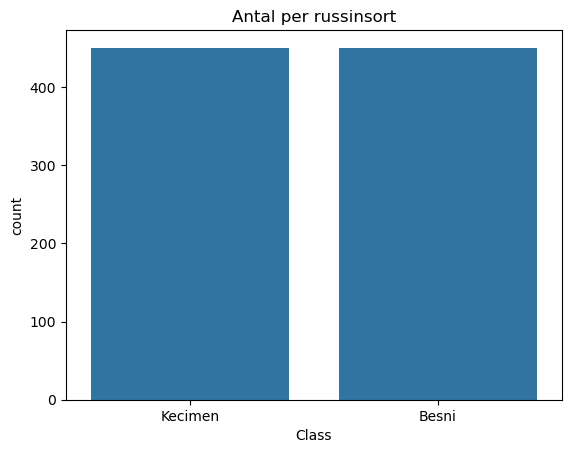

Class
Kecimen    450
Besni      450
Name: count, dtype: int64


In [390]:
counts = df["Class"].value_counts()

sns.countplot(data=df, x="Class")
plt.title("Antal per russinsort")
plt.show()
print(counts)

→ Modellen får lika många exempel av varje klass, vilket minskar risken för bias.

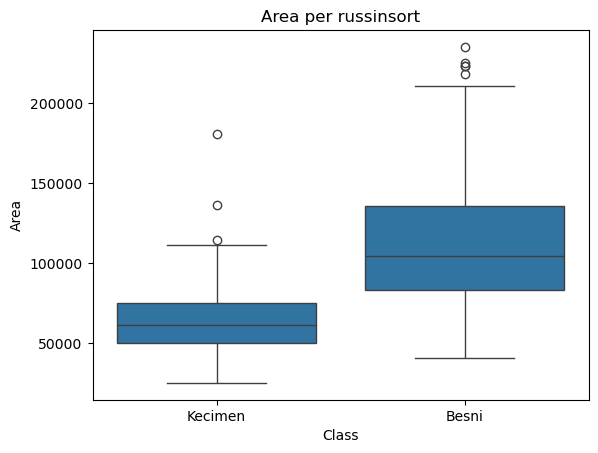

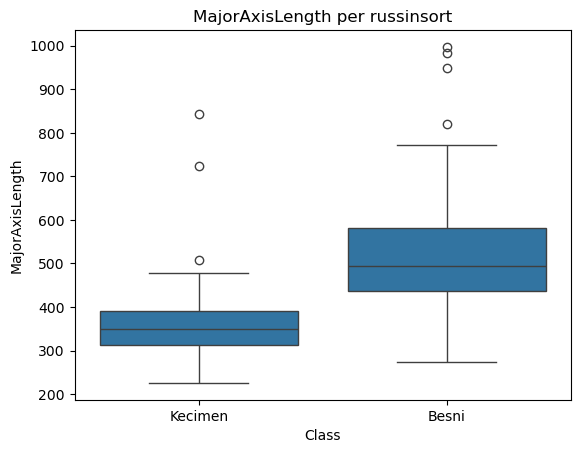

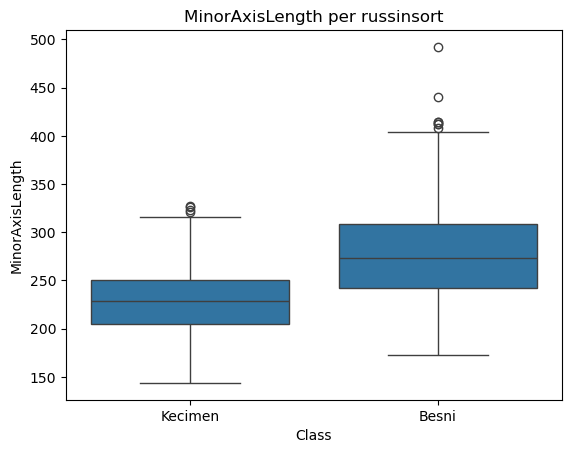

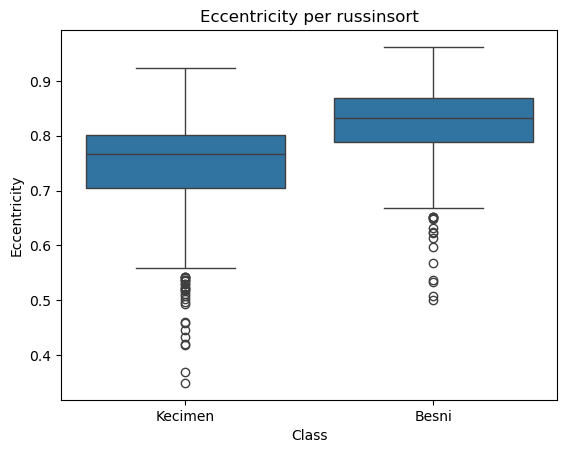

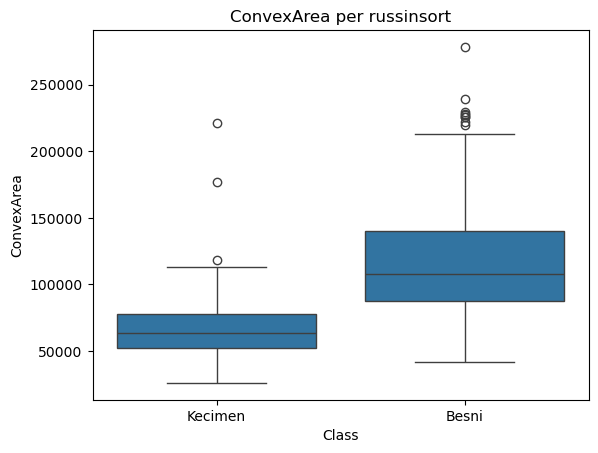

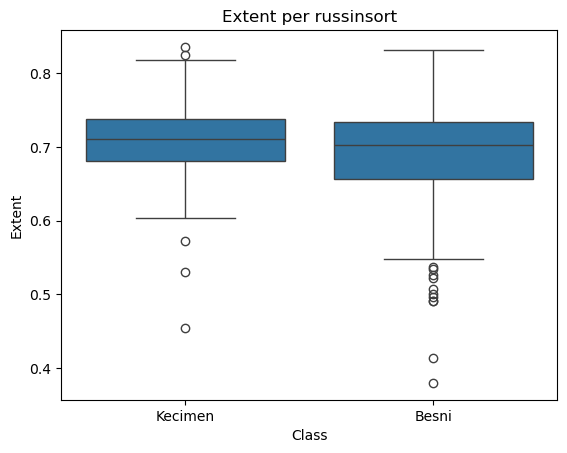

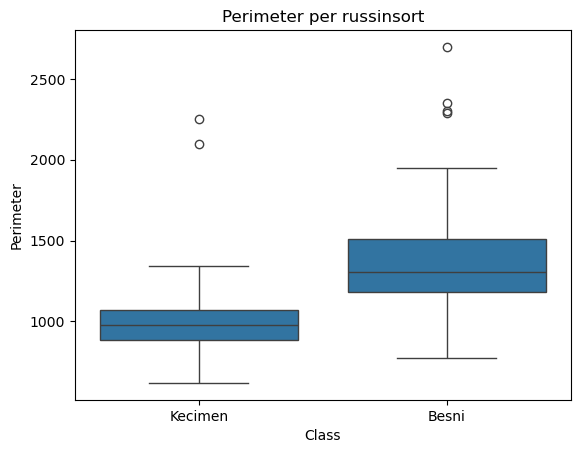

In [391]:
features = df.drop("Class", axis=1).columns

for col in features:
    sns.boxplot(data=df, x="Class", y=col)
    plt.title(f"{col} per russinsort")
    plt.show()

### Korrelation - heatmap

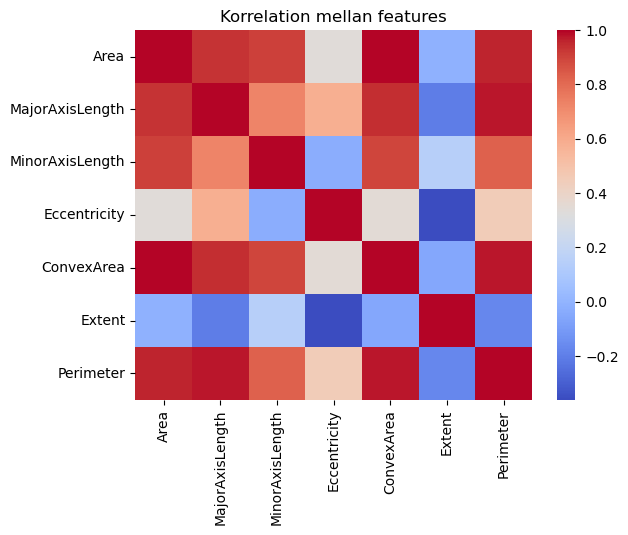

In [392]:
sns.heatmap(df.drop("Class", axis=1).corr(), cmap="coolwarm")
plt.title("Korrelation mellan features")
plt.show()

## Decision Tree

Förbereder data:

In [393]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Träna modellen:

In [394]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Prediktera:

In [395]:
y_pred = tree_model.predict(X_test)

Confusion Matrix:

In [396]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[70 20]
 [ 8 82]]


**Tolkning:**

	            	Predicted Kecimen	Predicted Besni 
	Actual Kecimen:	       rätt	             fel        
	Actual Besni:	       fel	             rätt       

Förtydligande:

In [397]:
def make_cmap(color):
    return LinearSegmentedColormap.from_list("", ["#FFFFFF", color])

colors = {
    "Random Forest": "#A65A37",
    "KNN (scaled)": "#7F634F",
    "XGBoost": "#6F8886",
    "Decision Tree": "#C2B280",
    "KNN": "#8F9779"
}

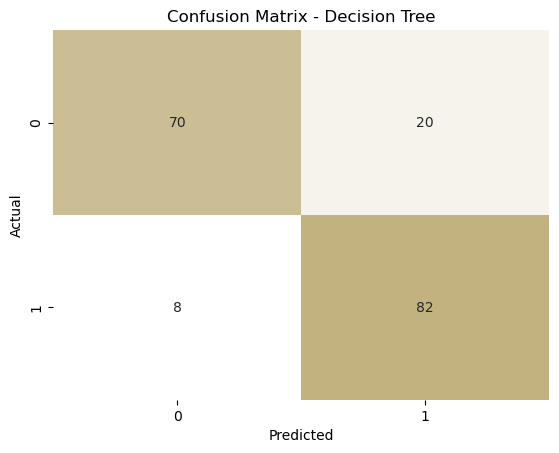

In [398]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=make_cmap(colors["Decision Tree"]),
    cbar=False
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Klass 0 (t.ex. Kecimen)  
70 rätt  
20 fel

➡️ ganska många fel här

Klass 1 (t.ex. Besni)  
82 rätt  
8 fel

➡️ mycket bättre träff  

Viktig insikt:  
Modellen har lättare att identifiera klass 1 än klass 0.

### Random Forest:

In [399]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### Confusion Matrix - Random Forest:

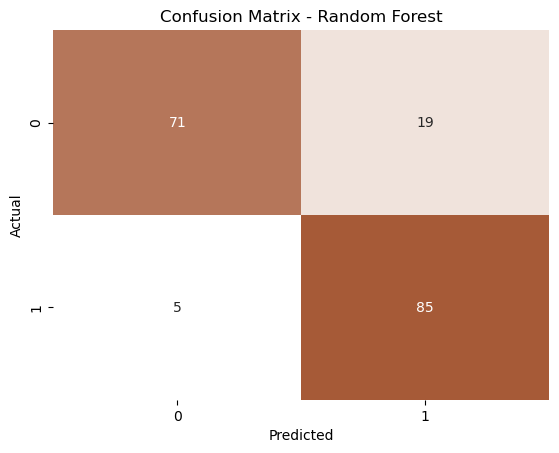

In [400]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap=make_cmap(colors["Random Forest"]),
    cbar=False
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Jämförelse med Decision Tree:**

	Modell            Fel klass 0	      Fel klass 1  
	Decision Tree:	       20	             8     
	Random Forest:	       19	             5     

Random Forest förbättrar modellen, men inte dramatiskt.  
Det betyder:
Datan är redan ganska “svår” i vissa områden  
Vissa russin är helt enkelt lika varandra → modellen kan inte skilja dem perfekt

**Decision Tree:**  
152 / 180 ≈ 84%  
**Random Forest:**  
(71 + 85) = 156 / 180 ≈ 86.7%  
→ +2–3% förbättring

### Feature Importance:

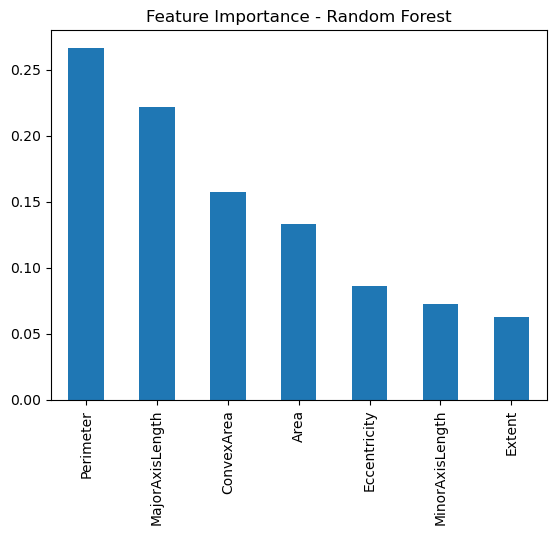

In [401]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.show()

**Tolkning:**  
Modellen använder främst:  
storlek + form för att skilja russinsorterna

Perimeter → omkrets  
MajorAxisLength → längd  
ConvexArea → “ytstorlek”

### Permutation Importance:

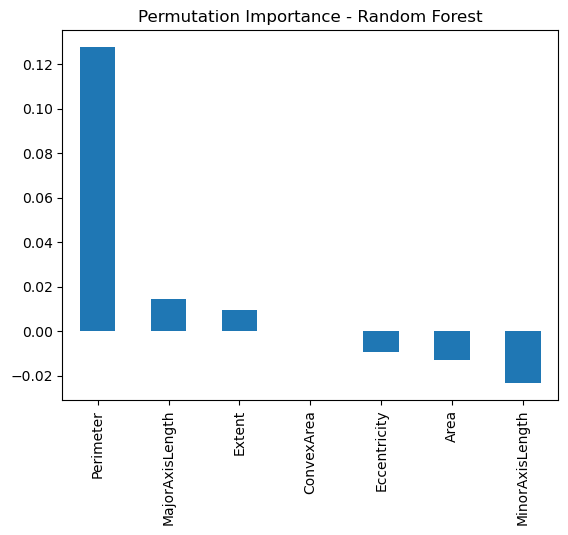

In [402]:
perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

perm_importance.plot(kind="bar")
plt.title("Permutation Importance - Random Forest")
plt.show()

**Jämförelse**  

    Metod	                        Vad den säger           
    Feature Importance	        “den här används mycket”
    Permutation Importance	    “den här är faktiskt viktig”

### Förstå misstag:

In [403]:
errors = X_test.copy()
errors["Actual"] = y_test
errors["Predicted"] = y_pred_rf

wrong = errors[errors["Actual"] != errors["Predicted"]]
wrong.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Actual,Predicted
502,71639,400.413959,231.620142,0.815717,76252,0.642462,1101.879,Besni,Kecimen
720,66793,362.231236,236.404449,0.757673,69506,0.684109,1024.169,Besni,Kecimen
639,61123,329.330220,257.268093,0.624299,70556,0.723264,1128.077,Besni,Kecimen
163,91831,463.357872,257.951128,0.830714,95560,0.710370,1252.762,Kecimen,Besni
822,62280,388.582055,205.514392,0.848695,63596,0.791440,977.906,Besni,Kecimen


#### Insikt:
Modellen gör fel när datapunkter ligger i gränslandet  
mellan klasserna, där egenskaperna överlappar.

**Enkel analogi:**

Två russinsorter:
- ena brukar vara större
- andra mindre

Men vissa russin:  
är “medelstora”

Då spelar det ingen roll hur bra modellen är  
→ de är objektivt svåra att skilja

---

### KNN:

In [404]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Prediktera:

In [405]:
y_pred_knn = knn_model.predict(X_test)

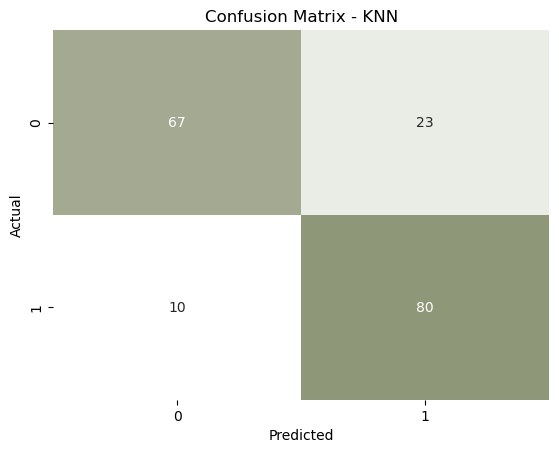

In [406]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap=make_cmap(colors["KNN"]),
    cbar=False
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Jämför med tidigare modeller:**  

    Modell	        Fel klass 0     Fel klass 1 
    Decision Tree	    20	            8       
    Random Forest	    19	            5       
    KNN	            23	            10      

**Tolkning:**  
KNN är sämre än Random Forest  
och även lite sämre än Decision Tree.  
**Konsekvens:**  
KNN bryr sig nästan bara om de största siffrorna (t.ex. Area)  
och ignorerar små features.  
**Slutsats:**  
KNN presterar sämre eftersom modellen är känslig för feature   scaling, och datasetet innehåller variabler med olika skalor.

### Lösning - Scaling (standardisering)
Gör så att alla features får ungefär samma skala:  
medelvärde = 0  
standardavvikelse = 1

In [407]:
scaler = StandardScaler() # skapa scaler
X_train_scaled = scaler.fit_transform(X_train) # träna scaler
X_test_scaled = scaler.transform(X_test) # använd på test data

#### Kör KNN igen (med scaled data):

In [408]:
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)

#### Ny confusion matrix:

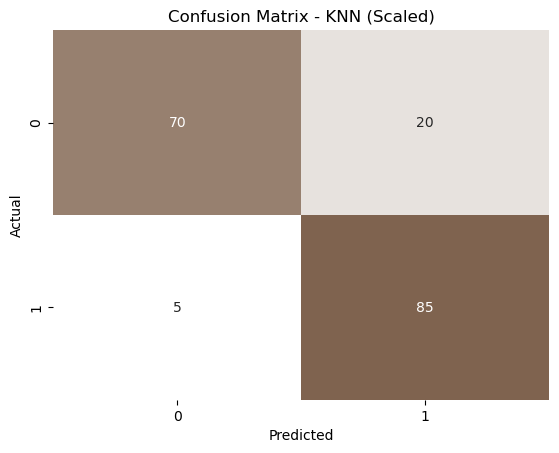

In [409]:
cm_knn_scaled = confusion_matrix(y_test, y_pred_knn_scaled)


sns.heatmap(
    cm_knn_scaled,
    annot=True,
    fmt="d",
    cmap=make_cmap(colors["KNN (scaled)"]),
    cbar=False
)

plt.title("Confusion Matrix - KNN (Scaled)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Jämförelse (alla modeller):**

    Modell	        Fel klass 0	 Fel klass 1 
    Decision Tree	    20	            8        
    Random Forest	    19	            5        
    KNN (utan scaling)  23	            10       
    KNN (scaled)	    20	            5        

KNN förbättrades markant efter scaling eftersom  
modellen baseras på avstånd mellan datapunkter,  
medan träd-baserade modeller inte påverkas på samma sätt.

**Viktig jämförelse mellan modeller**  

**KNN:**
- bygger på avstånd
- känslig för skala
- måste normaliseras

**Random Forest / Decision Tree:**  
- bygger på regler (if/else)
- bryr sig inte om skala

---

## XGBoost

Gör om target från text till siffror:

In [410]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Train/test split (med encoded y):

In [411]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

y_test_labels = le.inverse_transform(y_test)

Träna modellen:

In [412]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

C:\Users\emmyk\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:41:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Prediktera:

In [413]:
y_pred_xgb = xgb_model.predict(X_test)

y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

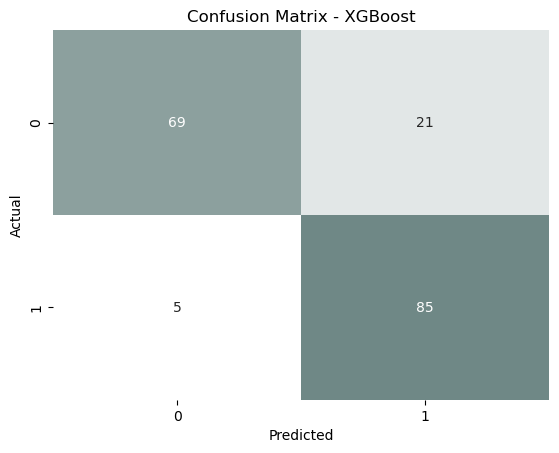

In [414]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap=make_cmap(colors["XGBoost"]),
    cbar=False
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Jämförelse med alla modeller:**  

    Modell	        Fel klass 0	Fel klass 1
    Decision Tree	    20	            8      
    Random Forest	    19	            5      
    KNN (scaled)	    20	            5      
    XGBoost	            21	            5      

## Slutsats:  

Mer avancerad modell ≠ alltid bättre resultat.  
Data och problemets natur avgör vilken modell som fungerar bäst.

---

### Räkna accuracy för alla modeller

In [415]:
from sklearn.metrics import accuracy_score

results = {
    "Decision Tree": accuracy_score(y_test_labels, y_pred),
    "Random Forest": accuracy_score(y_test_labels, y_pred_rf),
    "KNN": accuracy_score(y_test_labels, y_pred_knn),
    "KNN (scaled)": accuracy_score(y_test_labels, y_pred_knn_scaled),
    "XGBoost": accuracy_score(y_test_labels, y_pred_xgb_labels)
}

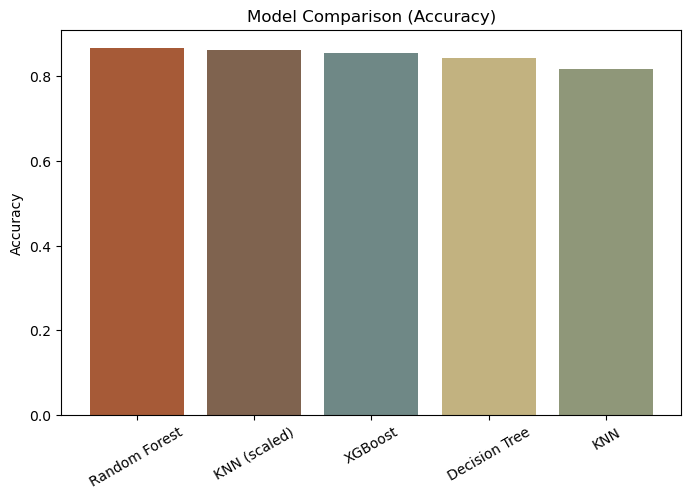

In [416]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

results_df.sort_values(by="Accuracy", ascending=False, inplace=True)

colors = ["#A65A37",
          "#7F634F",
          "#6F8886",
          "#C2B280",
          "#8F9779"]

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"], color=colors)
plt.title("Model Comparison (Accuracy)")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.show()